In [88]:
import pandas as pd
import sklearn
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn import datasets

In [105]:
dataset = datasets.load_iris()
X = dataset.data
Y = dataset.target
df = pd.DataFrame(data = X, columns = dataset.feature_names)
df['target'] = Y
print(df.head())
print(df.info())
print(dataset.target_names)

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  target
0                5.1               3.5                1.4               0.2       0
1                4.9               3.0                1.4               0.2       0
2                4.7               3.2                1.3               0.2       0
3                4.6               3.1                1.5               0.2       0
4                5.0               3.6                1.4               0.2       0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None
[

In [91]:
sse = []
sil_score = []
kmean1 = KMeans(n_clusters = 1, random_state=42,n_init = 10)
kmean1.fit(df[['sepal length (cm)','petal length (cm)']])
print(kmean1.inertia_)
sse.append(kmean1.inertia_)

566.4937333333334


In [92]:
for k in range(2,11):
    km = KMeans(n_clusters = k, random_state=42, n_init=10)
    km.fit(df[['sepal length (cm)','petal length (cm)']])
    sse.append(km.inertia_)
    sil = silhouette_score(
        df[['sepal length (cm)','petal length (cm)']],
        km.labels_
    )                                    
    sil_score.append(sil)

In [93]:
import matplotlib.pyplot as plt
sse = list(sse)

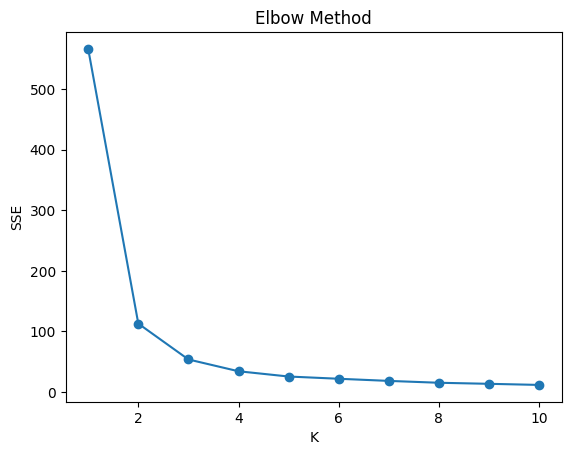

In [94]:
plt.plot(range(1,11), sse, marker='o')
plt.xlabel('K')
plt.ylabel('SSE')
plt.title('Elbow Method')
plt.show()

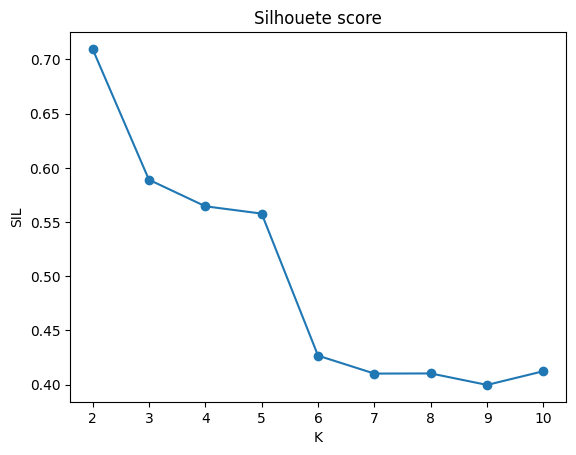

In [98]:
plt.plot(range(2,11), sil_score, marker='o')
plt.xlabel('K')
plt.ylabel('SIL')
plt.title('Silhouete score')
plt.show()

In [99]:
kmeans_final = KMeans(n_clusters=3,n_init=10,random_state=42)
kmeans_final.fit(df[['sepal length (cm)','petal length (cm)']])
df['kmeans'] = kmeans_final.labels_

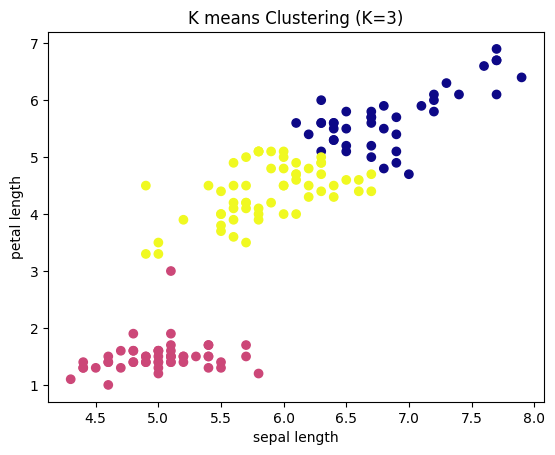

In [103]:
plt.scatter(df['sepal length (cm)'],df['petal length (cm)'],c = df['kmeans'], cmap='plasma')
plt.xlabel('sepal length')
plt.ylabel('petal length')
plt.title('K means Clustering (K=3)')
plt.show()

In [76]:
sil_score=silhouette_score(df[['sepal length (cm)','petal length (cm)']], df['kmeans'])
print(sil_score)


0.7097529826994816


In [82]:
ari = adjusted_rand_score(df['target'],df['kmeans'])
ari

0.5312290473980091

In [84]:
nmi = normalized_mutual_info_score(df['target'],df['kmeans'])
nmi

0.6398234233497638